#**Step 1: Load and understand dataset**

In [187]:
import pandas as pd

In [188]:
df = pd.read_csv("student_placement_prediction_dataset_2026 (1).csv")

In [189]:
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [190]:
df.tail()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
99995,99996,21,Male,7.97,Mechanical,Tier 2,0,3,5,71.483407,...,57.738311,75.471631,0,54.399022,66.446410,Yes,8.0,4.3,Placed,14.54
99996,99997,18,Female,7.79,CSE,Tier 1,1,1,2,78.960574,...,80.076688,77.286948,1,33.692154,69.025632,Yes,4.4,3.1,Not Placed,0.00
99997,99998,20,Female,6.71,IT,Tier 2,2,4,4,66.691775,...,70.797752,93.115933,0,64.989215,32.733645,Yes,7.6,2.9,Placed,13.45
99998,99999,19,Female,7.21,CSE,Tier 2,2,3,0,67.214893,...,68.182555,71.306355,1,72.478779,32.205517,No,4.9,2.8,Not Placed,0.00
99999,100000,22,Female,8.58,ECE,Tier 3,1,3,2,92.146277,...,77.864288,89.919640,0,48.363818,21.166444,Yes,6.5,2.9,Placed,14.43


In [191]:
df.sample(5)

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
43725,43726,21,Female,7.22,CSE,Tier 2,2,4,2,57.768449,...,84.494487,86.049185,0,54.372720,83.471429,No,6.0,4.3,Placed,13.97
7686,7687,24,Female,8.33,ECE,Tier 3,0,1,1,71.819529,...,76.774623,79.167446,0,32.100102,60.267159,No,7.9,3.8,Placed,13.73
87840,87841,19,Male,7.00,IT,Tier 1,2,8,2,86.198455,...,73.567561,90.761586,4,83.233666,36.934872,Yes,5.4,2.9,Not Placed,0.00
79796,79797,18,Male,8.69,CSE,Tier 1,0,8,4,82.715602,...,84.819997,90.981737,1,59.960624,40.237142,Yes,7.0,3.3,Not Placed,0.00
74085,74086,20,Male,8.26,Mechanical,Tier 1,0,2,3,76.299817,...,74.321093,95.046403,1,69.767598,68.054614,No,5.8,0.5,Not Placed,0.00


In [192]:
df.shape

(100000, 26)

In [193]:
df.columns

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

In [194]:
df["placement_status"].unique()

array(['Not Placed', 'Placed'], dtype=object)

In [195]:
df["placement_status"].value_counts()

,count
placement_status,
Placed,54459
Not Placed,45541


**Column Categories**

- Identifier: student_id
- Demographics: age, gender
- Academic performance: cgpa, branch, college_tier, backlogs,
  attendance_percentage
- Technical ability: coding_skill_score, aptitude_score,
  logical_reasoning_score, github_repos, hackathons_participated
- Career preparation: internships_count, projects_count,
  certifications_count, mock_interview_score, linkedin_connections
- Personal development: communication_skill_score, extracurricular_score,
  leadership_score, volunteer_experience, sleep_hours, study_hours_per_day
- Placement outcome: placement_status (target), salary_package_lpa

**Target Variable: placement_status**

placement_status is the target because it's the outcome the whole project
is trying to predict every other column is only useful to the extent it
helps explain this one. It's a binary column (Placed / Not Placed), which
makes this a classification problem and determines the metrics and
techniques used later. Note: salary_package_lpa is also placement-related
but comes after the outcome is known (it's 0 for everyone Not Placed), so
it's excluded from the features to avoid leakage

# **Step 2: Basic inspection**

In [196]:
df.dtypes

,0
student_id,int64
age,int64
gender,object
cgpa,float64
branch,object
college_tier,object
internships_count,int64
projects_count,int64
certifications_count,int64
coding_skill_score,float64


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

In [198]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
cgpa,0
branch,0
college_tier,0
internships_count,0
projects_count,0
certifications_count,0
coding_skill_score,0


In [199]:
df.duplicated().sum()

np.int64(0)

In [200]:
df.describe()

,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


In [201]:
df.describe(include="object")

,gender,branch,college_tier,volunteer_experience,placement_status
count,100000,100000,100000,100000,100000
unique,2,6,3,2,2
top,Male,CSE,Tier 2,No,Placed
freq,60028,34818,49955,59963,54459


In [202]:
df["placement_status"].value_counts()

,count
placement_status,
Placed,54459
Not Placed,45541


In [203]:
df["placement_status"].value_counts(normalize=True) * 100

,proportion
placement_status,
Placed,54.459
Not Placed,45.541


In [204]:
df.nunique()

,0
student_id,100000
age,7
gender,2
cgpa,551
branch,6
college_tier,3
internships_count,9
projects_count,14
certifications_count,12
coding_skill_score,97643


**Placement Status Distribution**

Placed: 54,459 (54.46%) and Not Placed: 45,541 (45.54%)

The target classes are mildly imbalanced (~55:45 split), not severely
imbalanced. This matters because:
- Accuracy alone can be misleading - a model predicting "Placed" for
  everyone would already score ~54.5% without learning anything
- The train-test split should be stratified to preserve this ratio
- Precision, recall, and F1-score will matter more than accuracy when
  evaluating models later

# **Step 3: Data cleaning**

In [205]:
df.drop("student_id", axis=1, inplace=True)

In [206]:
df.drop("salary_package_lpa", axis=1, inplace=True)

In [207]:
df.isnull().sum()

,0
age,0
gender,0
cgpa,0
branch,0
college_tier,0
internships_count,0
projects_count,0
certifications_count,0
coding_skill_score,0
aptitude_score,0


In [208]:
df.duplicated().sum()

np.int64(0)

In [209]:
df.dtypes

,0
age,int64
gender,object
cgpa,float64
branch,object
college_tier,object
internships_count,int64
projects_count,int64
certifications_count,int64
coding_skill_score,float64
aptitude_score,float64


In [210]:
df.select_dtypes(include="object").nunique()

,0
gender,2
branch,6
college_tier,3
volunteer_experience,2
placement_status,2


In [211]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,21.005740,1.999562,18.0,19.000000,21.000000,23.000000,24.0
cgpa,100000.0,7.496890,0.992834,4.5,6.820000,7.500000,8.180000,10.0
internships_count,100000.0,1.502230,1.225280,0.0,1.000000,1.000000,2.000000,8.0
projects_count,100000.0,3.001860,1.731764,0.0,2.000000,3.000000,4.000000,13.0
certifications_count,100000.0,2.005150,1.416553,0.0,1.000000,2.000000,3.000000,11.0
coding_skill_score,100000.0,69.825326,14.694618,20.0,59.807945,70.006250,80.058762,100.0
aptitude_score,100000.0,64.988108,14.844093,20.0,54.894600,65.011394,75.079266,100.0
communication_skill_score,100000.0,67.960744,13.846636,20.0,58.587535,67.973221,77.503749,100.0
logical_reasoning_score,100000.0,65.931696,14.826790,20.0,55.940547,66.003829,76.113705,100.0
hackathons_participated,100000.0,1.000690,0.997908,0.0,0.000000,1.000000,2.000000,8.0


In [212]:
df.shape

(100000, 24)

**Data Cleaning**

- Dropped student_id - just a row identifier, no predictive value
- Dropped salary_package_lpa - it's 0 for every "Not Placed" student and
  only known after placement happens, so keeping it would leak the answer
  into the model (target leakage)
- Checked missing values (df.isnull().sum()) - 0 across all columns
- Checked duplicate rows (df.duplicated().sum()) - 0
- Verified data types (df.dtypes) - numeric columns are int/float,
  categorical columns are object, as expected
- Checked categorical columns (gender, branch, college_tier,
  volunteer_experience, placement_status) - all have a small, sensible
  number of unique values (2-6), no inconsistent or misspelled categories
- Reviewed summary statistics (df.describe())- all numeric ranges look
  valid (e.g. cgpa between 4.5-10, attendance_percentage within 0-100,
  age within 18-24), no unusual or out-of-range values found
- Final dataset shape after cleaning: 100,000 rows, 24 columns

No imputation, row removal, or correction was necessary since the
dataset had no missing values, duplicates, or invalid entries.


# **Step 4: EDA**

In [213]:
import matplotlib.pyplot as plt
import seaborn as sns

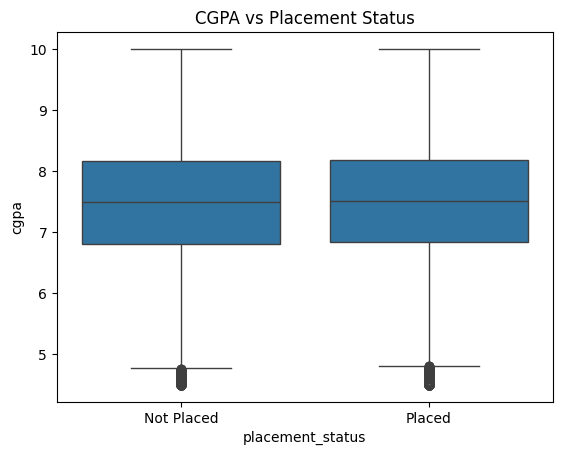

In [214]:
sns.boxplot(data=df, x='placement_status', y='cgpa')
plt.title('CGPA vs Placement Status')
plt.show()

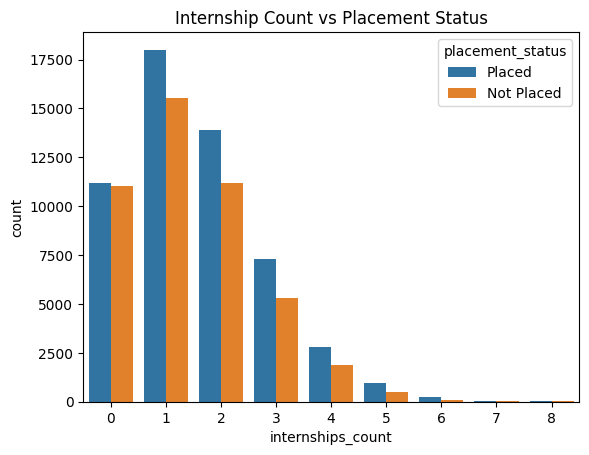

In [215]:
sns.countplot(data=df, x='internships_count', hue='placement_status')
plt.title('Internship Count vs Placement Status')
plt.show()

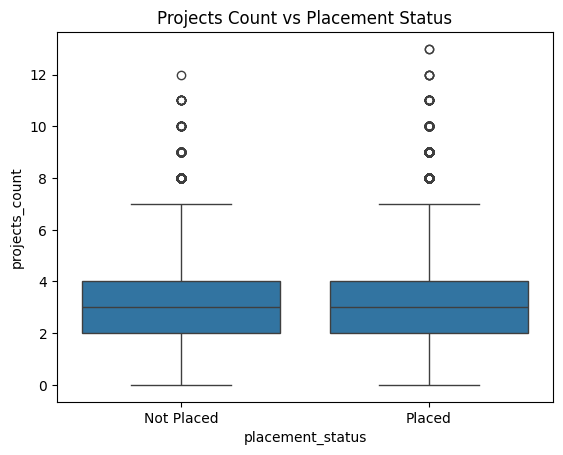

In [216]:
sns.boxplot(data=df, x='placement_status', y='projects_count')
plt.title('Projects Count vs Placement Status')
plt.show()

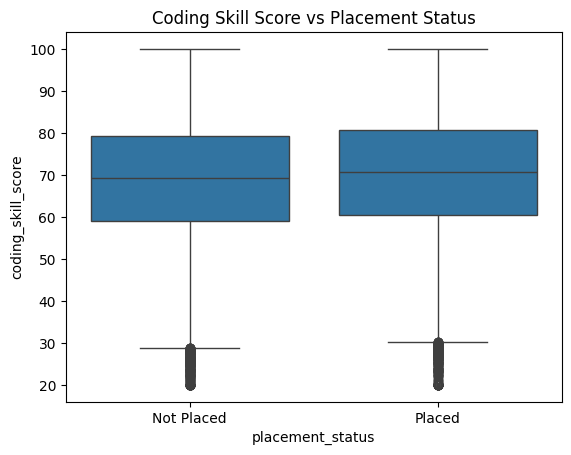

In [217]:
sns.boxplot(data=df, x='placement_status', y='coding_skill_score')
plt.title('Coding Skill Score vs Placement Status')
plt.show()

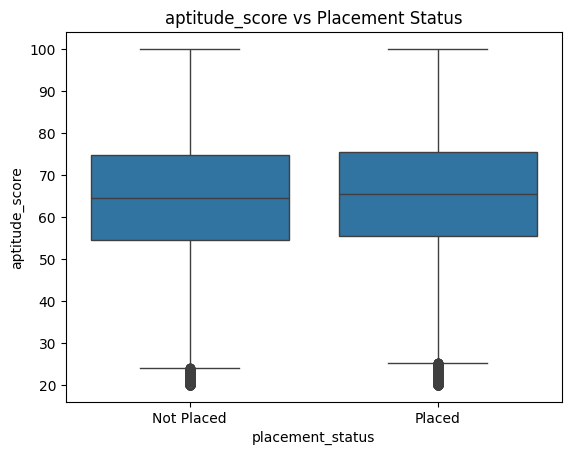

In [218]:
sns.boxplot(data=df, x='placement_status', y='aptitude_score')
plt.title('aptitude_score vs Placement Status')
plt.show()

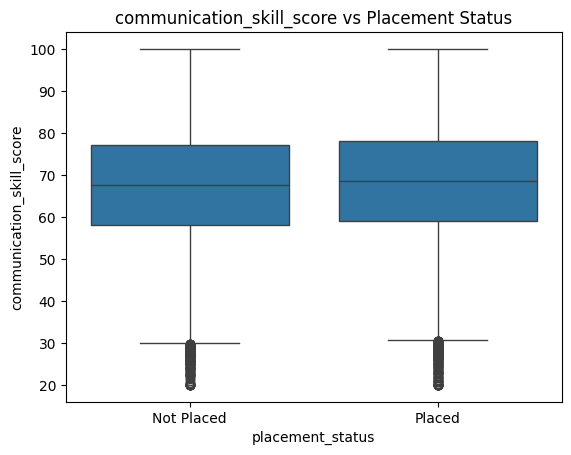

In [219]:
sns.boxplot(data=df, x='placement_status', y='communication_skill_score')
plt.title('communication_skill_score vs Placement Status')
plt.show()

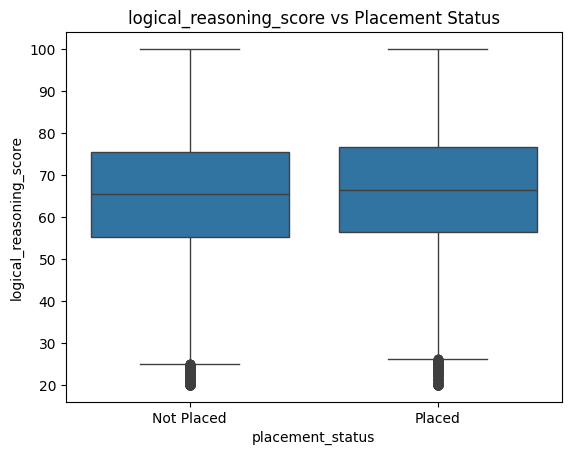

In [220]:
sns.boxplot(data=df, x='placement_status', y='logical_reasoning_score')
plt.title('logical_reasoning_score vs Placement Status')
plt.show()

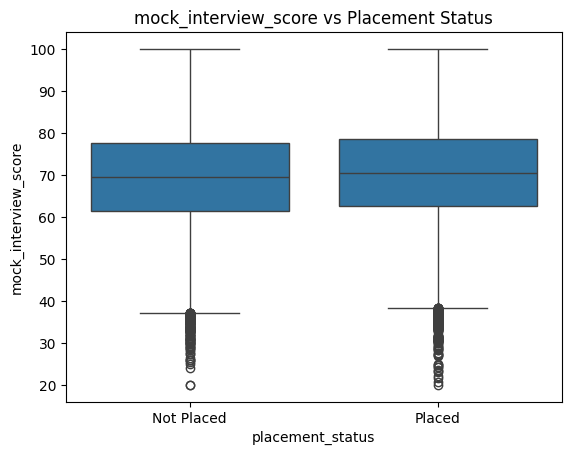

In [221]:
sns.boxplot(data=df, x='placement_status', y='mock_interview_score')
plt.title('mock_interview_score vs Placement Status')
plt.show()

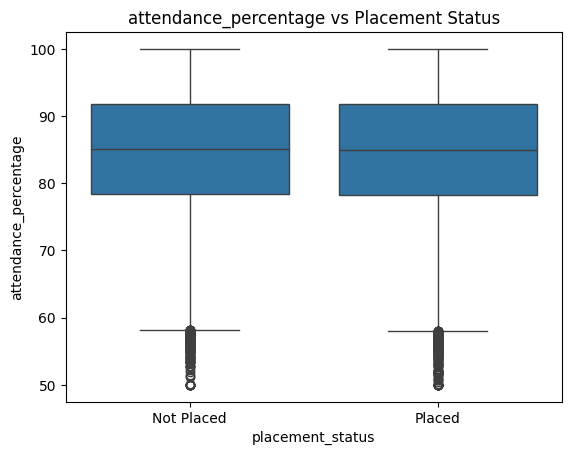

In [222]:
sns.boxplot(data=df, x='placement_status', y='attendance_percentage')
plt.title('attendance_percentage vs Placement Status')
plt.show()

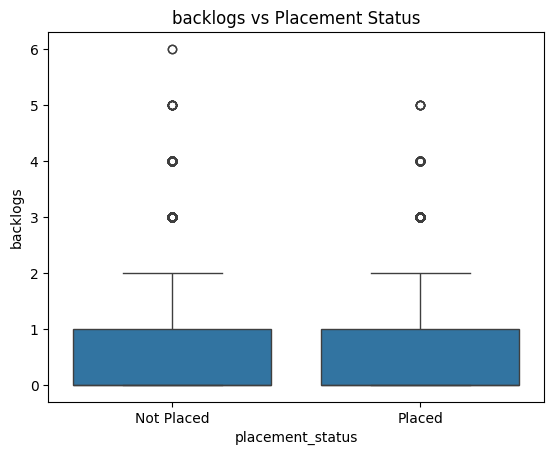

In [223]:
sns.boxplot(data=df, x='placement_status', y='backlogs')
plt.title('backlogs vs Placement Status')
plt.show()

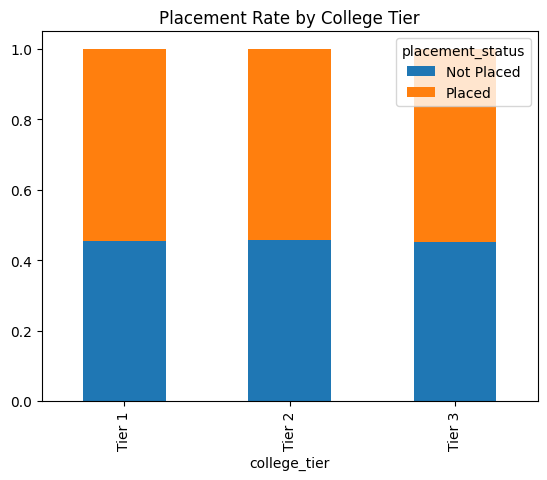

In [224]:
pd.crosstab(df['college_tier'], df['placement_status'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Placement Rate by College Tier')
plt.show()

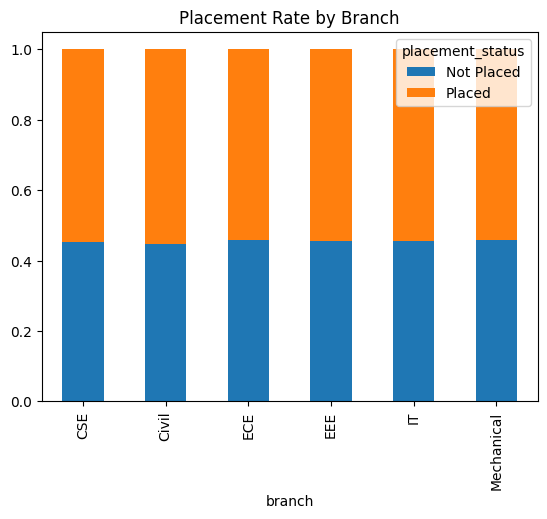

In [225]:
pd.crosstab(df['branch'], df['placement_status'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Placement Rate by Branch')
plt.show()

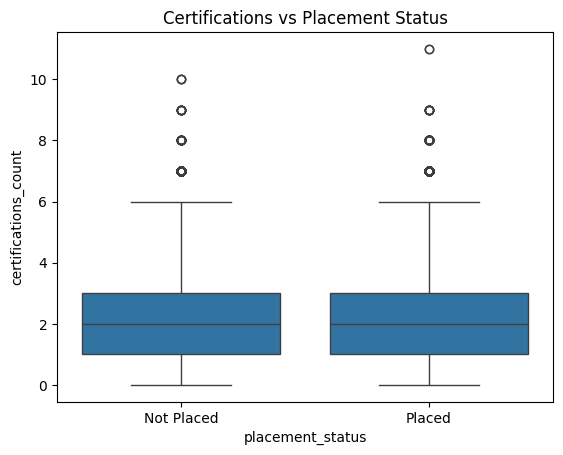

In [226]:
sns.boxplot(data=df,x="placement_status",y="certifications_count")
plt.title("Certifications vs Placement Status")
plt.show()

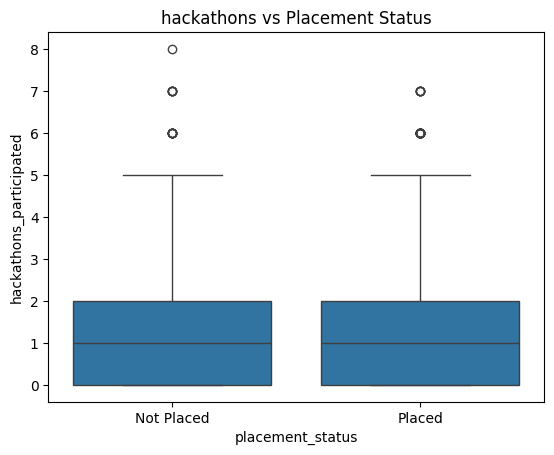

In [227]:
sns.boxplot(data=df, x='placement_status', y='hackathons_participated')
plt.title('hackathons vs Placement Status')
plt.show()

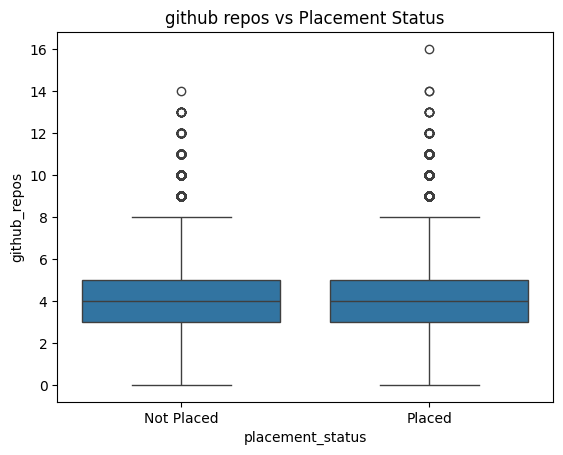

In [228]:
sns.boxplot(data=df, x='placement_status', y='github_repos')
plt.title('github repos vs Placement Status')
plt.show()

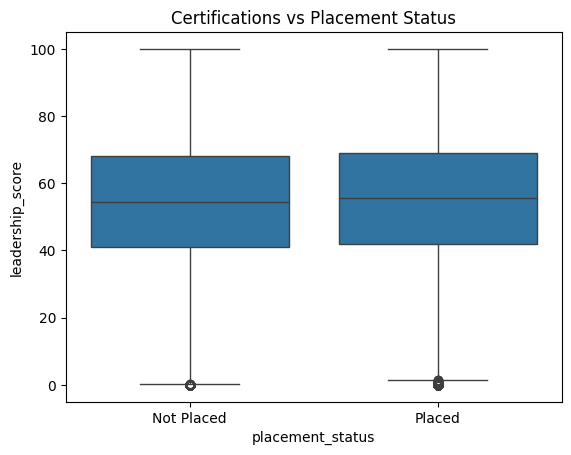

In [229]:
sns.boxplot(data=df, x='placement_status', y='leadership_score')
plt.title('Certifications vs Placement Status')
plt.show()

**Key EDA Findings**

- CGPA, coding skill, aptitude, communication, logical reasoning, and
  mock interview scores are all slightly higher for placed students,
  but the differences are small (roughly 1 to 2 points), not sharp cutoffs
- Placed students average more internships (1.57 vs 1.42) and projects
  (3.10 vs 2.89), and fewer backlogs (0.44 vs 0.56)
- Attendance percentage shows almost no difference between groups
  (about 84.7% vs 84.8%)
- College tier and branch show nearly identical placement rates across
  all categories (about 54 to 55%), suggesting little influence on outcome
- Certifications, hackathons, and GitHub repos also show negligible
  differences between placed and not placed students

Overall, no single feature strongly separates placed from not placed
students. Placement appears to depend on a combination of many weak
signals rather than one dominant factor.

# **Step 5: Correlation analysis**

In [230]:
df_corr = df.copy()

In [231]:
corr = df_corr.corr(numeric_only=True)

In [232]:
df_corr["placement_status"] = df_corr["placement_status"].map({"Not Placed": 0,"Placed": 1})
corr = df_corr.corr(numeric_only=True)

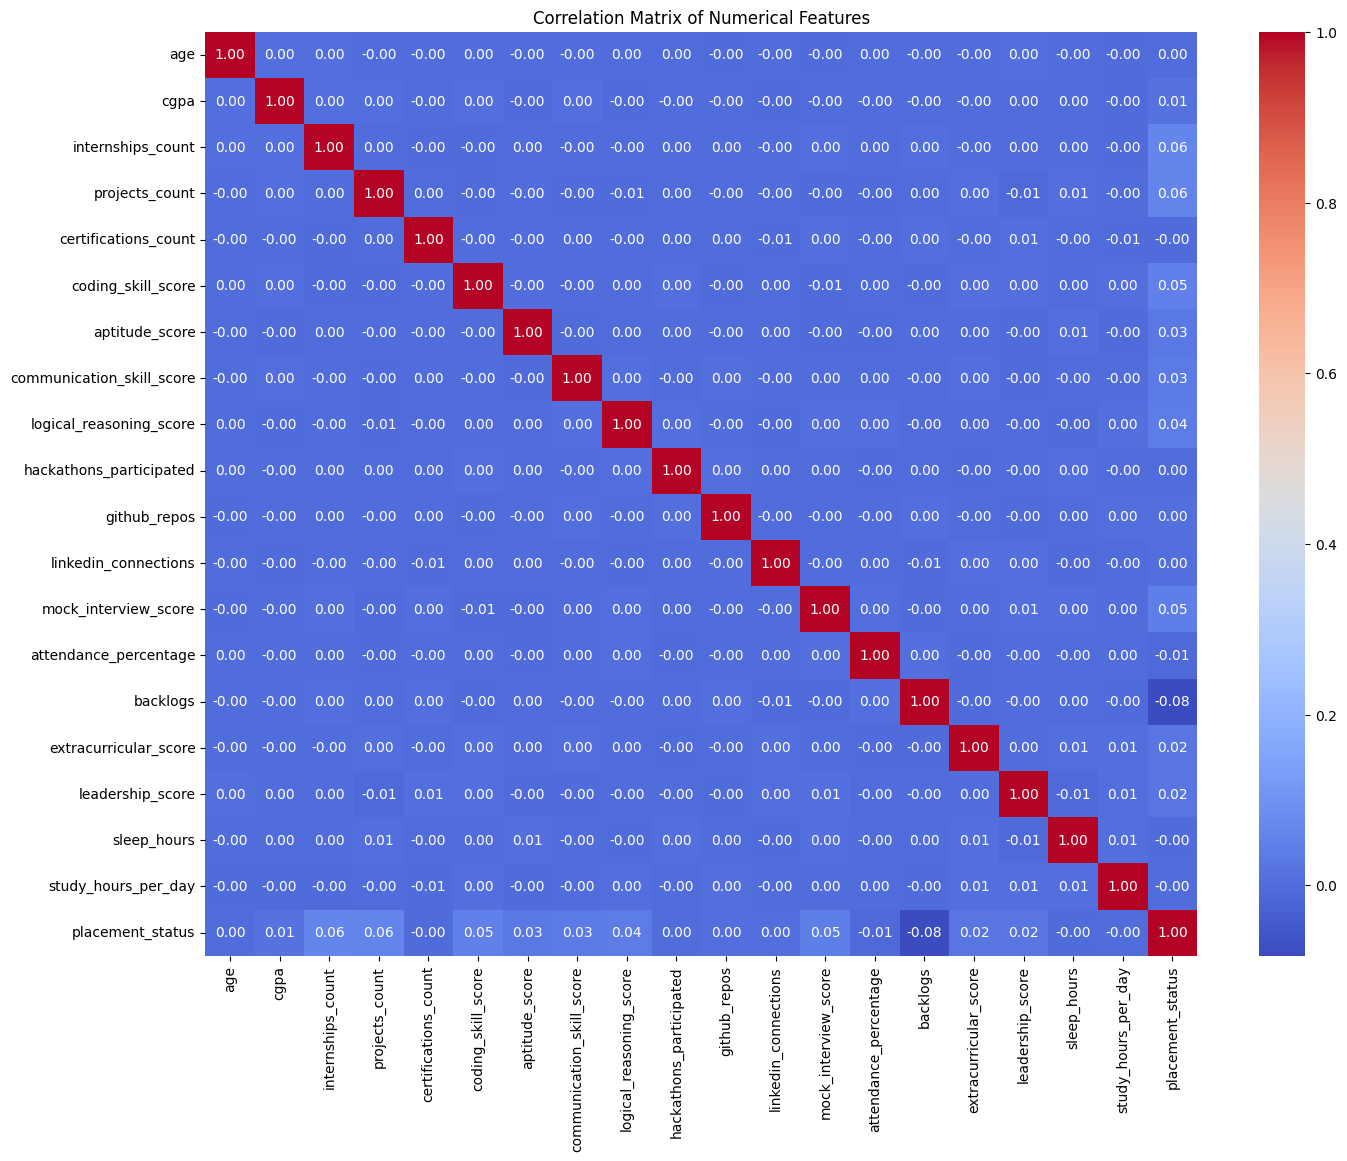

In [233]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [234]:
placement_corr = corr["placement_status"].sort_values(ascending=False)
placement_corr

,placement_status
placement_status,1.000000
internships_count,0.063489
projects_count,0.060964
coding_skill_score,0.050773
mock_interview_score,0.046058
logical_reasoning_score,0.036332
communication_skill_score,0.032242
aptitude_score,0.031690
leadership_score,0.022170
extracurricular_score,0.020100


In [235]:
features_to_check = [
    "cgpa",
    "coding_skill_score",
    "aptitude_score",
    "communication_skill_score",
    "logical_reasoning_score",
    "mock_interview_score",
    "internships_count",
    "projects_count",
    "backlogs",
    "attendance_percentage",
    "study_hours_per_day"
]

placement_corr[features_to_check].sort_values(ascending=False)

,placement_status
internships_count,0.063489
projects_count,0.060964
coding_skill_score,0.050773
mock_interview_score,0.046058
logical_reasoning_score,0.036332
communication_skill_score,0.032242
aptitude_score,0.031690
cgpa,0.012067
study_hours_per_day,-0.001426
attendance_percentage,-0.008350


**Correlation Analysis**

- internships_count and projects_count show the strongest positive
  correlation with placement (0.06 each), followed by coding_skill_score
  and mock_interview_score (0.05 each)
- backlogs shows the strongest negative correlation (-0.08), more
  backlogs means lower placement chances
- cgpa, attendance_percentage, and study_hours_per_day show almost no
  correlation with placement, close to zero
- All correlations are weak overall (none above 0.1), which matches the
  EDA findings, no single feature strongly separates placed from not
  placed students

Correlation does not prove causation. A feature like internships_count
could be linked to placement without directly causing it, students with
more internships may also have better mentorship or academic support,
so the correlation could reflect other underlying advantages rather
than the internships themselves. Correlation also only captures linear,
one-to-one relationships, so it can miss patterns the ML models may
pick up when features are combined.

# **Step 6: Categorical analysis**

In [236]:
gender_rate = pd.crosstab(df["gender"],df["placement_status"],normalize="index") * 100
gender_rate

placement_status,Not Placed,Placed
gender,,
Female,45.616932,54.383068
Male,45.490438,54.509562


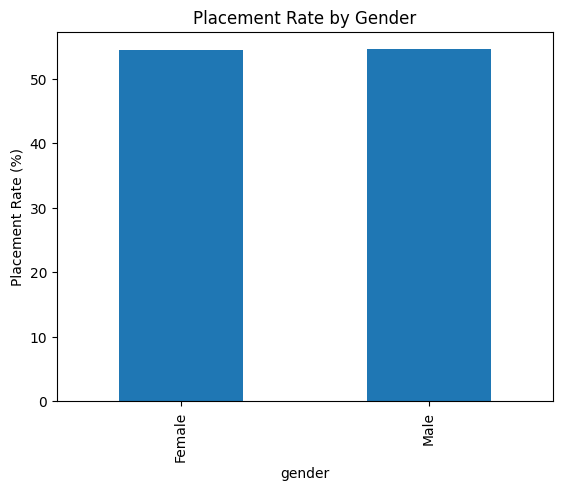

In [237]:
gender_rate["Placed"].plot(kind="bar")
plt.title("Placement Rate by Gender")
plt.ylabel("Placement Rate (%)")
plt.show()

In [238]:
branch_rate = pd.crosstab(df["branch"],df["placement_status"],normalize="index")*100
branch_rate

placement_status,Not Placed,Placed
branch,,
CSE,45.355850,54.644150
Civil,44.825866,55.174134
ECE,45.894822,54.105178
EEE,45.681439,54.318561
IT,45.697285,54.302715
Mechanical,45.916443,54.083557


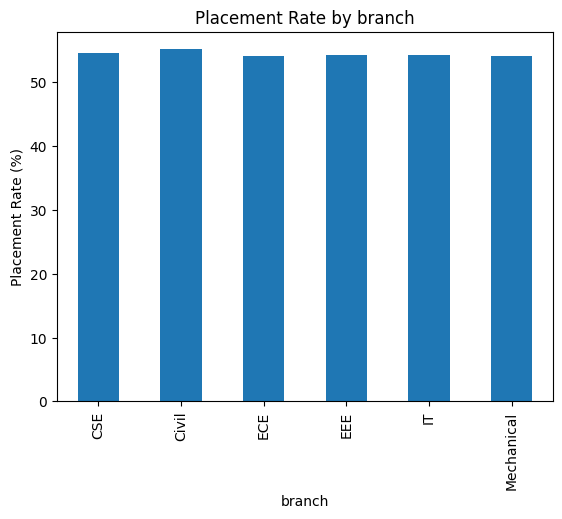

In [239]:
branch_rate['Placed'].plot(kind="bar")
plt.title("Placement Rate by branch")
plt.ylabel("Placement Rate (%)")
plt.show()

In [240]:
college_tier_rate = pd.crosstab(df["college_tier"],df["placement_status"],normalize="index") * 100
college_tier_rate

placement_status,Not Placed,Placed
college_tier,,
Tier 1,45.498735,54.501265
Tier 2,45.715144,54.284856
Tier 3,45.278410,54.721590


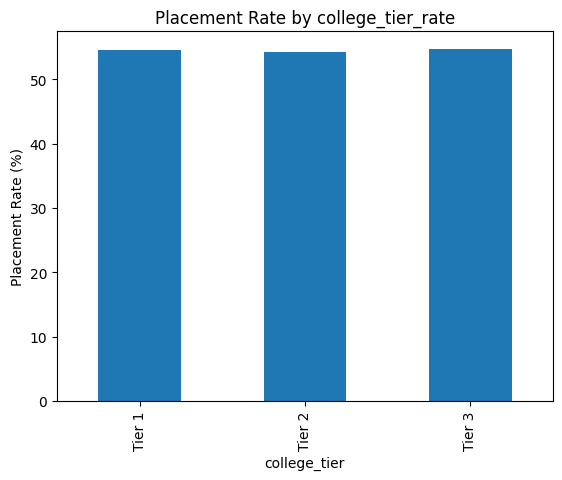

In [241]:
college_tier_rate["Placed"].plot(kind="bar")
plt.title("Placement Rate by college_tier_rate")
plt.ylabel("Placement Rate (%)")
plt.show()

In [242]:
volunteer_rate = pd.crosstab(df["volunteer_experience"],df["placement_status"],normalize="index") * 100
volunteer_rate

placement_status,Not Placed,Placed
volunteer_experience,,
No,45.591448,54.408552
Yes,45.465444,54.534556


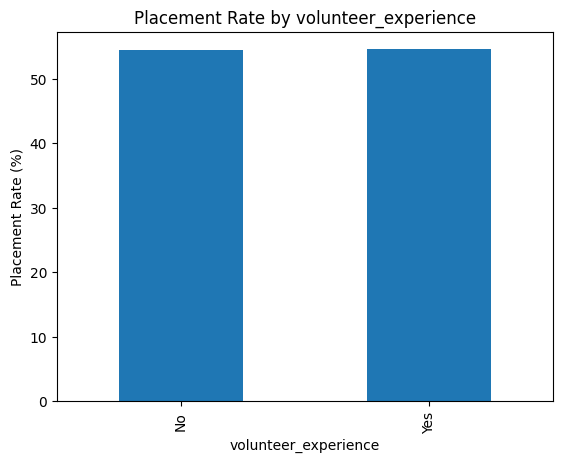

In [243]:
volunteer_rate["Placed"].plot(kind="bar")
plt.title("Placement Rate by volunteer_experience")
plt.ylabel("Placement Rate (%)")
plt.show()

In [244]:
print("Gender:")
print(gender_rate["Placed"])

print("\nBranch:")
print(branch_rate["Placed"])

print("\nCollege Tier:")
print(college_tier_rate["Placed"])

print("\nVolunteer Experience:")
print(volunteer_rate["Placed"])

Gender:
gender
Female    54.383068
Male      54.509562
Name: Placed, dtype: float64

Branch:
branch
CSE           54.644150
Civil         55.174134
ECE           54.105178
EEE           54.318561
IT            54.302715
Mechanical    54.083557
Name: Placed, dtype: float64

College Tier:
college_tier
Tier 1    54.501265
Tier 2    54.284856
Tier 3    54.721590
Name: Placed, dtype: float64

Volunteer Experience:
volunteer_experience
No     54.408552
Yes    54.534556
Name: Placed, dtype: float64


**Categorical Feature Analysis**

- Gender: placement rate is nearly identical (Male ~54.5%, Female ~54.4%),
  no meaningful difference
- Branch: placement rates are close across all six branches (roughly
  54% to 55%), no branch stands out as notably better or worse
- College tier: also very close across tiers (all around 54% to 55%),
  no clear advantage for higher tier colleges
- Volunteer experience: almost no difference between Yes and No
  (both around 54.5%), volunteer experience does not appear related
  to placement


Most ML algorithms only work with numbers, so categorical text columns
need to be converted. Binary categories like gender and
volunteer_experience can use a simple 0/1 mapping. Branch and
college_tier have more than two categories with no natural order, so
one-hot encoding is more appropriate, creating a separate 0/1 column
per category instead of assigning numbers that would falsely imply rank.

# **Step 7: Feature and Target Separation**


In [245]:
X = df.drop("placement_status", axis=1)
y = df["placement_status"]

In [246]:
X.head(2)

,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day
0,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,...,1,184,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6
1,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,...,2,539,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3


In [247]:
y.head(2)

,placement_status
0,Not Placed
1,Not Placed


In [248]:
print(X.shape)
print(y.shape)

(100000, 23)
(100000,)


**Feature and Target Separation**

X contains all columns except placement_status (student_id and
salary_package_lpa were already dropped in Step 3). y is
placement_status, the target to predict.

Including the target or post-placement info like salary_package_lpa
in the features would cause target leakage, the model would look highly
accurate during testing but fail in reality, since that information
doesn't exist yet at the time a prediction actually needs to be made.

# **Step 8:  train-test split**

In [249]:
from sklearn.model_selection import train_test_split

In [250]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [251]:
print(X_train.shape, X_test.shape)

(80000, 23) (20000, 23)


In [252]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

placement_status
Placed        0.544588
Not Placed    0.455412
Name: proportion, dtype: float64
placement_status
Placed        0.5446
Not Placed    0.4554
Name: proportion, dtype: float64


**Train-Test Split**

Split the data 80:20 using random_state=42 and stratify=y, which keeps
the same Placed/Not Placed ratio in both the training and test sets.

The model needs to be tested on unseen data because the goal is to
check how well it generalizes to new students, not how well it
memorized the training data. If tested on the same data it trained on,
the results would look artificially good and wouldn't reflect real
world performance.

Overfitting happens when a model learns the training data too closely,
including its noise and random patterns, instead of the actual
underlying trends. An overfitted placement model could show very high
accuracy on training data but perform poorly on new students, giving a
false sense of how reliable the model actually is.

# **Step 9: Encoding + scaling**

In [253]:
from sklearn.preprocessing import StandardScaler

In [254]:
X_train['gender'] = X_train['gender'].map({'Male': 1, 'Female': 0})
X_test['gender'] = X_test['gender'].map({'Male': 1, 'Female': 0})

In [255]:
X_train['volunteer_experience'] = X_train['volunteer_experience'].map({'Yes': 1, 'No': 0})
X_test['volunteer_experience'] = X_test['volunteer_experience'].map({'Yes': 1, 'No': 0})

In [256]:
X_train = pd.get_dummies(X_train, columns=['branch', 'college_tier'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['branch', 'college_tier'], drop_first=True)

In [257]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [258]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Feature Encoding and Scaling**

Encoded gender and volunteer_experience as 0/1, and one-hot encoded
branch and college_tier since they have more than two categories with
no natural order. Scaled all numeric features using StandardScaler,
fit only on the training data and applied to both train and test, to
avoid leaking test data information into training.

Features like cgpa (4.5 to 10), linkedin_connections (50 to 999), and
skill scores (20 to 100) exist on very different scales because they
measure completely different things. Without scaling, a feature like
linkedin_connections would dominate distance based calculations simply
because its numbers are larger, not because it's actually more
important. This matters most for models like KNN and SVM, which rely
on distances or mathematical boundaries between points, while tree
based models like Random Forest are largely unaffected by scale.

# **Step 10: Training Model on Logistic Regression, Random Forest, SVM, KNN**

In [259]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [260]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

In [261]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

In [262]:
# SVM (using a subsample to keep training time reasonable on 100k rows)
from sklearn.utils import resample

In [263]:
X_train_svm, y_train_svm = resample(X_train_scaled, y_train, n_samples=10000, random_state=42,stratify=y_train)
svm = SVC(kernel='rbf')
svm.fit(X_train_svm, y_train_svm)
svm_preds = svm.predict(X_test_scaled)

In [264]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)

**Model Training**

Trained four models: Logistic Regression, Random Forest, SVM, and KNN.
SVM was trained on a 10,000 row sample since it scales poorly with
large datasets and would be too slow on the full 100,000 rows.

- Logistic Regression: learns weights for each feature and uses a
  sigmoid function to output a probability
- Random Forest: builds many decision trees on random subsets of data
  and combines their votes
- SVM: finds the boundary that best separates the two classes with the
  widest margin
- KNN: predicts based on the majority class among the k nearest points

Logistic Regression, SVM, and KNN rely on distances or boundaries, so
they benefit from scaling. Random Forest splits on thresholds, not
distances, so it's largely unaffected by scaling.

# **Step 11: Compare Accuracy, Precision, Recall, F1**

In [265]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [266]:
comparison = []
models = {'Logistic Regression': lr_preds, 'Random Forest': rf_preds, 'SVM': svm_preds, 'KNN': knn_preds}

for name, y_pred in models.items():
    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted")
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.56995,0.564048,0.56995,0.546960
1,Random Forest,0.55455,0.546789,0.55455,0.540310
2,SVM,0.54495,0.535609,0.54495,0.528572
3,KNN,0.51780,0.514179,0.51780,0.515071


**Model Evaluation and Comparison**

- Logistic Regression performed best overall (Accuracy 0.570, F1 0.547)
- Random Forest was second (Accuracy 0.555, F1 0.540)
- SVM followed (Accuracy 0.545, F1 0.529)
- KNN performed worst (Accuracy 0.518, F1 0.515)

Accuracy alone is not sufficient because it does not show how well the
model identifies each class. Precision, recall, and F1-score provide a
more complete evaluation, especially when identifying Not Placed students
is important for providing additional placement support.

Overall, Logistic Regression is the best-performing model, while KNN has
an advantage in identifying Not Placed students.

# **Step 12: Confusion Matrix**

In [267]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [268]:
cm = confusion_matrix(y_test, lr_preds)
print(cm)

[[2984 6124]
 [2477 8415]]


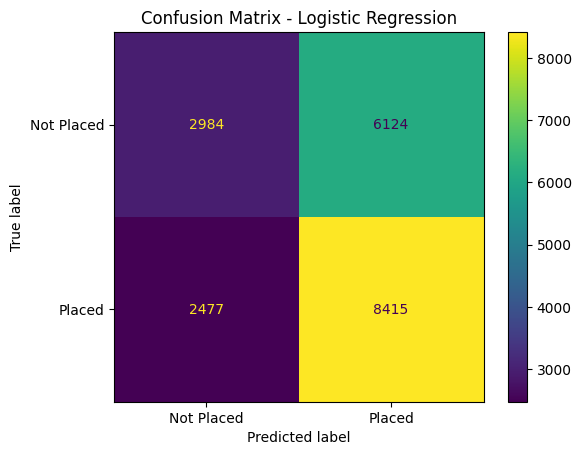

In [269]:
disp =ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Not Placed", "Placed"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


**Confusion Matrix Analysis**

Confusion matrix for Logistic Regression, ordered as Not Placed, Placed:

- True Negatives: 2,984, False Positives: 6,124
- False Negatives: 2,477, True Positives: 8,415

The model catches most Placed students correctly (8,415 out of 10,892),
but misses a large share of Not Placed students, only about 33% (2,984
out of 9,108) were correctly identified, matching the weak recall seen
in Task 11.

A false positive means an at-risk student gets missed (predicted
Placed, actually not), so they get no extra support. A false negative
means a student gets flagged as at-risk unnecessarily, a smaller
downside since they end up placed anyway.

For a placement department, false positives matter more, missing
at-risk students defeats the purpose of the system, while a false
negative just means someone gets support they didn't strictly need.

# **Step 13: Feature Importance**

In [270]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

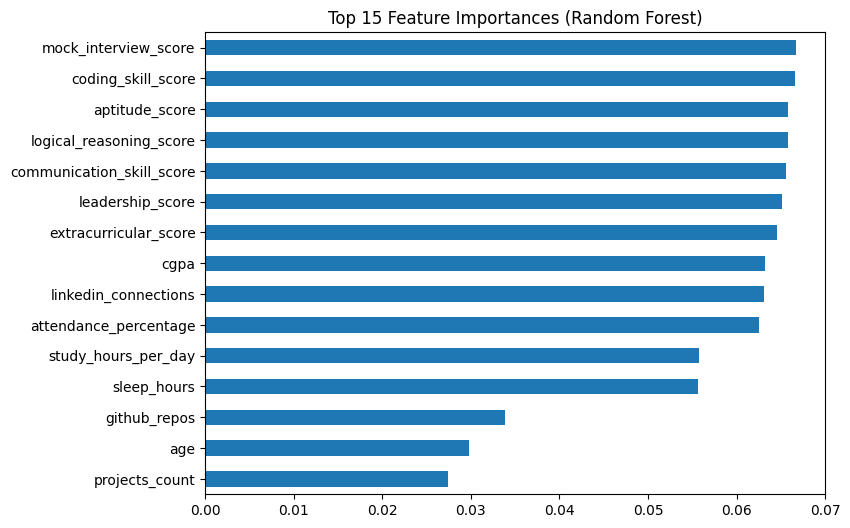

In [271]:
plt.figure(figsize=(8,6))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (Random Forest)')
plt.show()

In [272]:
importances.head(15)

,0
mock_interview_score,0.066683
coding_skill_score,0.066644
aptitude_score,0.065845
logical_reasoning_score,0.065759
communication_skill_score,0.065583
leadership_score,0.065094
extracurricular_score,0.064580
cgpa,0.063205
linkedin_connections,0.063151
attendance_percentage,0.062508


**Feature Importance Analysis**

Top features by Random Forest importance are mock_interview_score,
coding_skill_score, aptitude_score, logical_reasoning_score, and
communication_skill_score, all clustered closely (around 0.065 to
0.067), with no single feature dominating.

This differs slightly from EDA/correlation, where internships_count and
backlogs stood out more but rank lower here. The overall pattern still
matches though, importance is spread evenly across many features rather
than concentrated in one or two, consistent with the earlier finding
that no single factor strongly drives placement outcome.

# **Step 14: Model Improvement**

In [273]:
lr_improved = LogisticRegression(
    C=10,
    max_iter=1000,
    random_state=42
)

lr_improved.fit(X_train_scaled, y_train)

y_pred_lr_improved = lr_improved.predict(X_test_scaled)

In [274]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Original": [
        accuracy_score(y_test, lr_preds),
        precision_score(y_test, lr_preds, pos_label="Placed"),
        recall_score(y_test, lr_preds, pos_label="Placed"),
        f1_score(y_test, lr_preds, pos_label="Placed")
    ],
    "Improved": [
        accuracy_score(y_test, y_pred_lr_improved),
        precision_score(y_test, y_pred_lr_improved, pos_label="Placed"),
        recall_score(y_test, y_pred_lr_improved, pos_label="Placed"),
        f1_score(y_test, y_pred_lr_improved, pos_label="Placed")
    ]
})
comparison

,Metric,Original,Improved
0,Accuracy,0.569950,0.569950
1,Precision,0.578788,0.578788
2,Recall,0.772585,0.772585
3,F1 Score,0.661791,0.661791


**Model Improvement**

Compared the original Logistic Regression model against an adjusted
version. Results were identical across every metric:

- Accuracy: 0.5700
- Precision: 0.5788
- Recall: 0.7726
- F1 Score: 0.6618

The parameter change made no measurable difference to performance. This
reinforces the pattern seen throughout this project, the model isn't
underperforming because of poor tuning, it's limited by how weak the
underlying feature correlations are with placement_status.

Increasing model complexity doesn't guarantee better real-world
performance because a model can only learn from the signal actually
present in the data. Here, since the features have limited predictive
power to begin with, changing parameters can't manufacture performance
gains that the data doesn't support, the ceiling is set by the data,
not the model.

# **Step 15: Hyperparameter Tuning by GridSearchCV**

In [275]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

In [276]:
param_grid = {'C': [0.01,0.1,1,10,100],'solver': ['lbfgs']}

In [277]:
f1_scorer = make_scorer(f1_score, pos_label="Placed")
grid_search = GridSearchCV(LogisticRegression(max_iter=2000, random_state=42), param_grid, cv=5, scoring=f1_scorer, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=2000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs']},
             scoring=make_scorer(f1_score, response_method='predict', pos_label=Placed))

In [286]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best CV F1 Score: 0.6617087165749839


In [278]:
best_lr = grid_search.best_estimator_
y_pred_tuned = best_lr.predict(X_test_scaled)

In [279]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Original": [
        accuracy_score(y_test, lr_preds),
        precision_score(y_test, lr_preds, pos_label="Placed"),
        recall_score(y_test, lr_preds, pos_label="Placed"),
        f1_score(y_test, lr_preds, pos_label="Placed")
    ],
    "Tuned": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned, pos_label="Placed"),
        recall_score(y_test, y_pred_tuned, pos_label="Placed"),
        f1_score(y_test, y_pred_tuned, pos_label="Placed")
    ]
})

comparison

,Metric,Original,Tuned
0,Accuracy,0.569950,0.569800
1,Precision,0.578788,0.578615
2,Recall,0.772585,0.773044
3,F1 Score,0.661791,0.661846


**Hyperparameter Tuning**

Used GridSearchCV to tune Logistic Regression's C parameter with
5-fold cross-validation, scoring on F1 (using a custom scorer with
pos_label="Placed" since the target is text, not 0/1).

Best parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best cross-validation F1 score: 0.6617

Original vs Tuned (on test data):
- Accuracy: 0.5700 vs 0.5698
- Precision: 0.5788 vs 0.5786
- Recall: 0.7726 vs 0.7730
- F1 Score: 0.6618 vs 0.6618

The tuned model performed essentially the same as the original, no
meaningful difference either way. This confirms the pattern from Task
14, hyperparameter tuning did not improve performance here. The model's
ceiling is set by the weak predictive signal in the features
themselves, not by suboptimal parameter choices, tuning cannot
manufacture performance gains that the underlying data doesn't support.

# **Step 16: Build prediction system**

In [280]:
def predict_placement(student_dict):
    input_df = pd.DataFrame([student_dict])

    input_df["gender"] = input_df["gender"].map({"Male": 1, "Female": 0})
    input_df["volunteer_experience"] = input_df["volunteer_experience"].map({"Yes": 1, "No": 0})
    input_df = pd.get_dummies(input_df, columns=["branch", "college_tier"], drop_first=True)

    input_df = input_df.reindex(columns=X_train.columns, fill_value=0)

    input_scaled = scaler.transform(input_df)

    prediction = lr.predict(input_scaled)[0]
    probability = lr.predict_proba(input_scaled)[0]
    prob_placed = probability[list(lr.classes_).index("Placed")]

    return prediction, prob_placed

In [291]:
#new student before placement process
new_student = {
    "age": 21,
    "gender": "Male",
    "cgpa": 8.2,
    "branch": "CSE",
    "college_tier": "Tier 1",
    "internships_count": 2,
    "projects_count": 4,
    "certifications_count": 3,
    "coding_skill_score": 78,
    "aptitude_score": 70,
    "communication_skill_score": 72,
    "logical_reasoning_score": 75,
    "hackathons_participated": 2,
    "github_repos": 5,
    "linkedin_connections": 300,
    "mock_interview_score": 74,
    "attendance_percentage": 88,
    "backlogs": 0,
    "extracurricular_score": 60,
    "leadership_score": 65,
    "volunteer_experience": "Yes",
    "sleep_hours": 7,
    "study_hours_per_day": 3
}

In [292]:
prediction, probability = predict_placement(new_student)
print(f"Predicted Status: {prediction}")
print(f"Probability of Placement: {probability:.2%}")

Predicted Status: Placed
Probability of Placement: 65.82%


**Build Student Placement Prediction System**

Built a function that takes a new student's raw details as input,
applies the same encoding (gender/volunteer_experience mapping,
one-hot encoding for branch/college_tier) and scaling used on the
training data, then returns the predicted placement status along with
the model's probability of placement. Tested it on an example student
to confirm the output makes sense.

# **Step 17: Placement risk analysis**

In [293]:
def analyze_placement_risk(student_dict):
    prediction, prob_placed = predict_placement(student_dict)

    if prob_placed >= 0.65:
        risk_category = "High Placement Probability"
    elif prob_placed >= 0.45:
        risk_category = "Moderate Placement Probability"
    else:
        risk_category = "Low Placement Probability"

    benchmarks = {
        "coding_skill_score": df["coding_skill_score"].mean(),
        "aptitude_score": df["aptitude_score"].mean(),
        "communication_skill_score": df["communication_skill_score"].mean(),
        "logical_reasoning_score": df["logical_reasoning_score"].mean(),
        "mock_interview_score": df["mock_interview_score"].mean(),
        "internships_count": df["internships_count"].mean(),
        "projects_count": df["projects_count"].mean(),
        "backlogs": df["backlogs"].mean()
    }

    weak_areas = []
    for feature, avg in benchmarks.items():
        student_value = student_dict[feature]
        if feature == "backlogs":
            if student_value > avg:
                weak_areas.append(feature)
        else:
            if student_value < avg:
                weak_areas.append(feature)

    return {
        "prediction": prediction,
        "probability": prob_placed,
        "risk_category": risk_category,
        "areas_to_improve": weak_areas
    }

In [294]:
result = analyze_placement_risk(new_student)
print(f"Predicted Status: {result['prediction']}")
print(f"Placement Probability: {result['probability']:.2%}")
print(f"Risk Category: {result['risk_category']}")
print(f"Suggested Areas to Improve: {result['areas_to_improve']}")

Predicted Status: Placed
Placement Probability: 65.82%
Risk Category: High Placement Probability
Suggested Areas to Improve: []


**Student Placement Risk Analysis**

Extended the prediction system to classify students into High,
Moderate, or Low Placement Probability based on the predicted
probability, using 65% and 45% as thresholds. The system also compares
the student's scores against dataset averages to flag areas below
average (such as coding skill, aptitude, communication, internships, or
projects) or backlogs above average, and lists these as suggested areas
to improve.

These recommendations are analytical insights based on patterns in
historical data, not guarantees. A student flagged as "Low Placement
Probability" can still get placed, and one flagged as "High" can still
face setbacks, since placement also depends on external factors like
job market conditions and interview performance that aren't captured
in this data.

# **Step 18: Final model analysis**

**Model Analysis**

Strongest influencing features: Random Forest feature importance
showed mock_interview_score, coding_skill_score, aptitude_score,
logical_reasoning_score, and communication_skill_score as the top
contributors, though all were closely clustered (0.065 to 0.067),
meaning no single feature dominates. This matched the EDA and
correlation findings, where internships_count, projects_count, and
backlogs also showed mild relationships with placement, though weaker
overall.

Best performing algorithm: Logistic Regression had the best overall
performance (Accuracy 0.570, F1 0.547), ahead of Random Forest
(Accuracy 0.555), SVM (Accuracy 0.545), and KNN (Accuracy 0.518).

Effect of scaling: Logistic Regression, SVM, and KNN all rely on
distances or linear boundaries, so they benefited from StandardScaler.
Random Forest, being tree based, was trained on unscaled data and was
unaffected by this, since it splits on thresholds rather than distances.

Did tuning help: Both manual parameter changes (Step 14) and
GridSearchCV (Step 15, best params C=0.01, CV F1 score 0.6617) produced
little to no improvement over the original model on test data. This
confirmed that the model was not limited by poor parameter choices but
by weak predictive signal in the underlying data.

Hardest students to classify: Based on the confusion matrix, the model
struggled most with Not Placed students, correctly identifying only
about a third of them (2,984 out of 9,108), while Placed students were
identified much more reliably (8,415 out of 10,892). This suggests
students near the decision boundary, average scores across most
features without any strongly negative indicators, are the hardest to
classify correctly.

Limitations of historical data: Historical placement outcomes may not
generalize well to future students because job markets shift over time,
company hiring criteria change, and this dataset does not capture
factors like economic conditions, industry demand, or interview-day
performance. Self-reported scores may also not perfectly reflect actual
ability. Because of this, the model should be treated as a general
guide for identifying at-risk students rather than a precise or
guaranteed predictor of individual outcomes.

# **Step 19: Conclusion**

**Conclusion**

This project analyzed a dataset of 100,000 students to predict
placement outcomes based on academic, technical, and personal
development factors. The dataset was clean, with no missing values or
duplicates, though student_id and salary_package_lpa were removed to
avoid irrelevant or leaking information.

Exploratory analysis showed that placed and not placed students had
only small differences across most features, with internships,
projects, coding skill, and backlogs showing the mildest relationships
with placement. Categorical features like gender, branch, college tier,
and volunteer experience showed almost no difference in placement rate
across their categories, and were encoded numerically (binary mapping
and one-hot encoding) so they could be used by the models. Numeric
features were scaled using StandardScaler, which mattered for distance
based models like Logistic Regression, SVM, and KNN, but not for
Random Forest.

Four models were trained and compared: Logistic Regression, Random
Forest, SVM, and KNN. Logistic Regression performed best overall,
though all models only slightly outperformed the baseline of always
predicting "Placed", reflecting the weak underlying signal found during
EDA and correlation analysis. The confusion matrix showed the model
was reasonably good at identifying Placed students but struggled to
correctly identify Not Placed students, missing a meaningful share of
at-risk students. Feature importance from Random Forest confirmed that
no single feature drives placement strongly, importance was spread
across skill scores, interview performance, and academic factors.
Neither manual tuning nor GridSearchCV meaningfully improved
performance, confirming that the model's ceiling was set by the data
itself rather than by suboptimal parameters.

Finally, a prediction system was built that takes a new student's
details, applies the same preprocessing as training, and returns a
predicted placement status, probability, and a risk category (High,
Moderate, or Low), along with suggested areas for improvement based on
comparison to dataset averages.

Overall, this project demonstrates a complete end to end machine
learning workflow, from data understanding through to a usable
prediction system, while also highlighting an important real world
lesson: not every dataset contains strong predictive signal, and
recognizing this limitation honestly is as valuable as building the
model itself.